✅ Dataset loaded: 205 rows × 10 columns

📋 STEP 1 — Initial Audit
  Duplicates : 5
  Missing    : 422 cells

🗑️  STEP 2 — Drop High-Missingness Columns
  Nothing to drop

👯 STEP 3 — Remove Duplicates
  Removed 5 duplicates (205 → 200 rows)

🩹 STEP 4 — Handle Missing Values
  'full_name': 40 nulls → mode ('Alice Johnson')
  'email': 40 nulls → mode ('BOB@EXAMPLE.COM')
  'phone': 80 nulls → mode ('(555) 246-8101')
  'signup_date': 40 nulls → mode ('10/22/2023')
  'country': 40 nulls → mode ('CANADA')
  'city': 40 nulls → mode ('LONDON')
  'age': 40 nulls → median (29.50)
  'purchase_amt': 60 nulls → median (120.50)
  'status': 40 nulls → mode ('Active')

📧 STEP 5 — Clean Emails
  'email': 40 invalid emails removed

📅 STEP 6 — Standardize Dates
  'signup_date': → YYYY-MM-DD

🔤 STEP 7 — Standardize Text
  'full_name': title case applied
  'phone': title case applied
  'signup_date': title case applied
  'country': title case applied
  'city': title case applied
  'status': title case appli

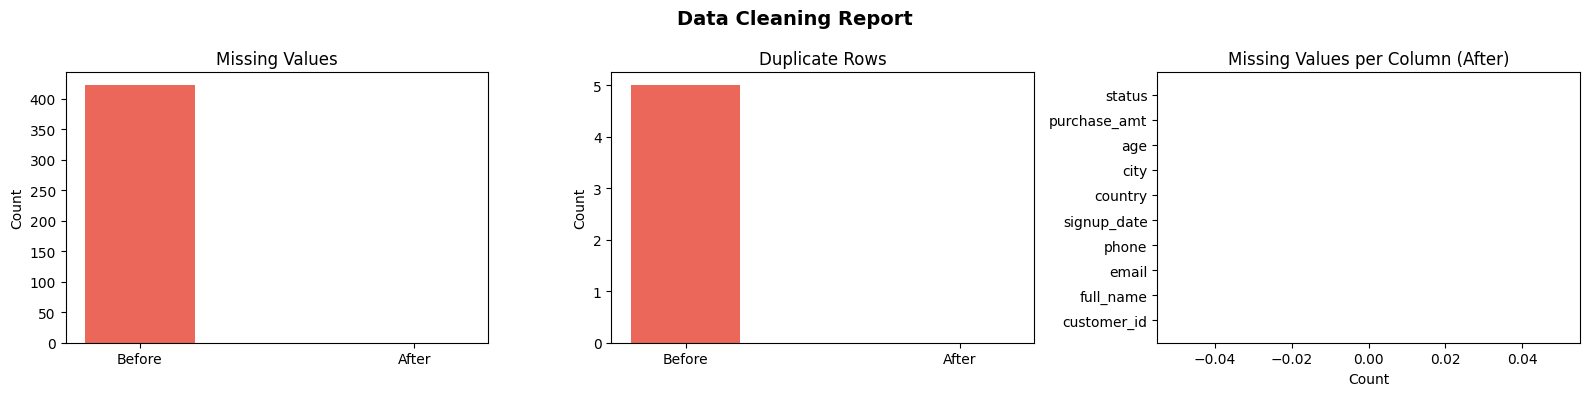

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Files downloaded!


In [ ]:
# ============================================================
#  DATA CLEANING & PREPROCESSING PIPELINE
#  Internship Task 2 | Google Colab
# ============================================================

!pip install pandas numpy openpyxl -q

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

# ── SAMPLE DATASET (replace with your own CSV if needed) ────
np.random.seed(42)
n = 200
data = {
    'customer_id' : list(range(1, n+1)),
    'full_name'   : (['Alice Johnson','Bob Smith',None,'David Lee','EVA MARTINEZ']*(n//5))[:n],
    'email'       : (['alice@example.com','BOB@EXAMPLE.COM','invalid-email',None,'eva@example.com']*(n//5))[:n],
    'phone'       : (['+1-555-123-4567','555.987.6543',None,'(555) 246-8101',None]*(n//5))[:n],
    'signup_date' : (['2023-05-10','10/22/2023','2023/11/01',None,'March 3 2024']*(n//5))[:n],
    'country'     : (['USA','united kingdom','CANADA',None,'australia']*(n//5))[:n],
    'city'        : (['new york','LONDON','Toronto',None,'sydney']*(n//5))[:n],
    'age'         : ([28,34,None,150,22,45,-5,None,31,27]*(n//10))[:n],
    'purchase_amt': ([120.5,None,-50.0,340.0,89.99,None,0,205.0,None,430.0]*(n//10))[:n],
    'status'      : (['active','inactive','Active',None,'INACTIVE']*(n//5))[:n],
}
df = pd.DataFrame(data)
df = pd.concat([df, df.iloc[[0,5,10,15,20]]], ignore_index=True)
df_original = df.copy()

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ── STEP 1: AUDIT ────────────────────────────────────────────
print("\n📋 STEP 1 — Initial Audit")
print(f"  Duplicates : {df.duplicated().sum()}")
print(f"  Missing    : {df.isnull().sum().sum()} cells")

# ── STEP 2: DROP HIGH-MISSING COLUMNS ───────────────────────
print("\n🗑️  STEP 2 — Drop High-Missingness Columns")
to_drop = df.columns[df.isnull().mean() > 0.60].tolist()
if to_drop:
    df.drop(columns=to_drop, inplace=True)
    print(f"  Dropped: {to_drop}")
else:
    print("  Nothing to drop")

# ── STEP 3: REMOVE DUPLICATES ────────────────────────────────
print("\n👯 STEP 3 — Remove Duplicates")
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Removed {before - len(df)} duplicates ({before} → {len(df)} rows)")

# ── STEP 4: FILL MISSING VALUES ──────────────────────────────
print("\n🩹 STEP 4 — Handle Missing Values")
for col in df.columns:
    n_miss = df[col].isnull().sum()
    if n_miss == 0: continue
    if pd.api.types.is_numeric_dtype(df[col]):
        val = df[col].median()
        df[col].fillna(val, inplace=True)
        print(f"  '{col}': {n_miss} nulls → median ({val:.2f})")
    else:
        val = df[col].mode()[0] if not df[col].dropna().empty else 'Unknown'
        df[col].fillna(val, inplace=True)
        print(f"  '{col}': {n_miss} nulls → mode ('{val}')")

# ── STEP 5: CLEAN EMAILS ─────────────────────────────────────
print("\n📧 STEP 5 — Clean Emails")
pattern = re.compile(r'^[\w\.\+\-]+@[\w\-]+\.[a-z]{2,}$', re.IGNORECASE)
for col in [c for c in df.columns if 'email' in c.lower()]:
    df[col] = df[col].astype(str).str.strip().str.lower()
    invalid = ~df[col].apply(lambda x: bool(pattern.match(x)))
    df.loc[invalid, col] = np.nan
    print(f"  '{col}': {invalid.sum()} invalid emails removed")

# ── STEP 6: STANDARDIZE DATES ────────────────────────────────
print("\n📅 STEP 6 — Standardize Dates")
date_cols = [c for c in df.columns if any(k in c.lower() for k in ['date','dob','time'])]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)
    df[col] = df[col].dt.strftime('%Y-%m-%d')
    print(f"  '{col}': → YYYY-MM-DD")

# ── STEP 7: STANDARDIZE TEXT ─────────────────────────────────
print("\n🔤 STEP 7 — Standardize Text")
for col in [c for c in df.columns if df[c].dtype == object and 'email' not in c.lower()]:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col].replace({'None': np.nan, 'Nan': np.nan}, inplace=True)
    print(f"  '{col}': title case applied")

# ── STEP 8: FIX OUTLIERS & NEGATIVES ────────────────────────
print("\n📊 STEP 8 — Fix Outliers & Negatives")
for col in df.select_dtypes(include=[np.number]).columns:
    neg = (df[col] < 0).sum()
    if neg > 0:
        df.loc[df[col] < 0, col] = np.nan
        print(f"  '{col}': {neg} negatives → NaN")
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    out = ((df[col] < lo) | (df[col] > hi)).sum()
    if out:
        df[col] = df[col].clip(lo, hi)
        print(f"  '{col}': {out} outliers capped")

# ── STEP 9: SECOND PASS FILL ─────────────────────────────────
for col in df.columns:
    n_miss = df[col].isnull().sum()
    if n_miss == 0: continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].median(), inplace=True)
    elif not df[col].dropna().empty:
        df[col].fillna(df[col].mode()[0], inplace=True)

# ── STEP 10: OPTIMIZE DTYPES ─────────────────────────────────
print("\n🏷️  STEP 10 — Optimize Data Types")
for col in df.columns:
    if df[col].dtype == object and df[col].nunique() / len(df) < 0.15:
        df[col] = df[col].astype('category')
        print(f"  '{col}': → category")

# ── FINAL REPORT ─────────────────────────────────────────────
miss_before = df_original.isnull().sum().sum()
miss_after  = df.isnull().sum().sum()
health      = round(100 - (miss_after / df.size * 100), 1)

print("\n" + "="*50)
print("  ✅ CLEANING COMPLETE")
print("="*50)
print(f"  Rows    : {len(df_original)} → {len(df)}  ({len(df_original)-len(df)} removed)")
print(f"  Columns : {df_original.shape[1]} → {df.shape[1]}")
print(f"  Missing : {miss_before} → {miss_after}")
print(f"  Health  : {health}%")
print("="*50)

# ── CHARTS ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Data Cleaning Report", fontsize=14, fontweight='bold')

# Before vs After
labels = ['Missing Cells', 'Duplicate Rows']
axes[0].bar(['Before','After'],
            [df_original.isnull().sum().sum(), df.isnull().sum().sum()],
            color=['#e74c3c','#2ecc71'], alpha=0.85, width=0.4)
axes[0].set_title('Missing Values')
axes[0].set_ylabel('Count')

axes[1].bar(['Before','After'],
            [df_original.duplicated().sum(), df.duplicated().sum()],
            color=['#e74c3c','#2ecc71'], alpha=0.85, width=0.4)
axes[1].set_title('Duplicate Rows')
axes[1].set_ylabel('Count')

# Missing per column after
miss_col = df.isnull().sum()
bar_colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in miss_col]
axes[2].barh(miss_col.index, miss_col.values, color=bar_colors)
axes[2].set_title('Missing Values per Column (After)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('cleaning_report.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SAVE & DOWNLOAD ──────────────────────────────────────────
df.to_csv('cleaned_dataset.csv', index=False)
files.download('cleaned_dataset.csv')
files.download('cleaning_report.png')
print("\n📥 Files downloaded!")